주사위 4개를 던질 때 적어도 6이 두 개 나올 확률

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)  # 항상 같은 숫자가 나옵니다(재현 가능해야 함)

# -----------------------------
# 1. 시뮬레이션 설정
# -----------------------------
n_trials = 100000  # 실험 횟수 (충분히 크게)
n_dice = 4         # 주사위 개수

# -----------------------------
# 2. 주사위 던지기 시뮬레이션 : = “주사위를 여러 번 던진 결과를 표 형태로 한 번에 생성”
# -----------------------------
# 각 행: 1번 실험  -- 100,000 행 : 실험횟수
# 각 열: 각 주사위 결과 -- 주사위 개수 4개
# 벡터화
dice = np.random.randint(1, 7, size=(n_trials, n_dice))  # 1~6(주사위값)=1이상 7미만 정수 생성


# -----------------------------
# 3. "6이 나왔는지"를 0/1로 변환
# -----------------------------
# 6이면 1, 아니면 0
is_six = (dice == 6).astype(int)

# -----------------------------
# 4. 각 실험에서 6의 개수 --> 3이 되어야 6이 나온 개수를 셀 수 있다.
# -----------------------------
num_six = is_six.sum(axis=1)

# -----------------------------
# 5. 우리가 구하는 확률
# -----------------------------
prob_at_least_2 = np.mean(num_six >= 2)

print("적어도 2개 6이 나올 확률:", prob_at_least_2)

# -----------------------------
# 6. 주변확률 (Marginal Distribution)
# -----------------------------
# X = "6의 개수"의 분포
marginal_dist = pd.Series(num_six).value_counts(normalize=True).sort_index()

print("\n[주변확률분포 P(X=k)]")
print(marginal_dist)

# -----------------------------
# 7. 공분산 & 상관계수
# -----------------------------
# 각 주사위가 서로 독립인지 확인
df = pd.DataFrame(is_six, columns=["D1", "D2", "D3", "D4"])

cov_matrix = df.cov()
corr_matrix = df.corr()

print("\n[공분산 행렬]")
print(cov_matrix)

print("\n[상관계수 행렬]")
print(corr_matrix)

적어도 2개 6이 나올 확률: 0.13227

[주변확률분포 P(X=k)]
0    0.48499
1    0.38274
2    0.11582
3    0.01575
4    0.00070
Name: proportion, dtype: float64

[공분산 행렬]
          D1        D2        D3        D4
D1  0.139332 -0.000081  0.000345  0.000416
D2 -0.000081  0.138064 -0.000021  0.000543
D3  0.000345 -0.000021  0.137837  0.000519
D4  0.000416  0.000543  0.000519  0.138832

[상관계수 행렬]
          D1        D2        D3        D4
D1  1.000000 -0.000587  0.002493  0.002992
D2 -0.000587  1.000000 -0.000151  0.003920
D3  0.002493 -0.000151  1.000000  0.003754
D4  0.002992  0.003920  0.003754  1.000000


 한 카페에는 고객이 평균적으로 4분마다 1명씩 도착한다. 고객 도착 간격은 지수분포를 따른다고 가정할 때,하루 동안 500명의 고객이 도착했다고 가정하고, 고객 간 도착 시간 500개를 시뮬레이션을 파이썬의 Pandas의 random.expotential()로 구현

평균 도착 간격: 4.017236716473617
총 소요 시간: 2008.618358236808

[상위 5개 데이터]
   inter_arrival_time  arrival_time
0            1.877072      1.877072
1           12.040486     13.917558
2            5.266983     19.184541
3            3.651770     22.836311
4            0.678499     23.514811


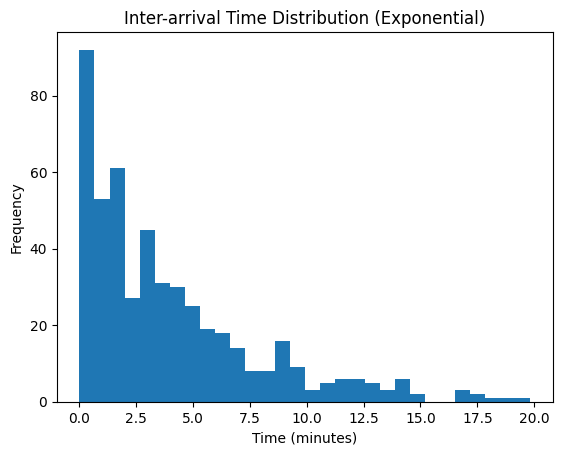

In [2]:
# ============================================
# 0. 라이브러리 로드
# ============================================
import numpy as np
import pandas as pd

# ============================================
# 1. 재현성 확보 (매번 같은 결과)
# ============================================
np.random.seed(42)

# ============================================
# 2. 문제 설정
# ============================================
# 평균 4분마다 고객 1명 도착
# → 지수분포에서 평균 = scale = 4
mean_interval = 4  # 분

# 하루 동안 고객 수 (문제에서 500명 가정)
n_customers = 500

# ============================================
# 3. 지수분포에서 도착 간격 생성
# ============================================
# np.random.exponential(scale, size)
# - scale = 평균 (여기서는 4분)
# - size = 생성할 샘플 수 (500개)
inter_arrival_times = np.random.exponential(
    scale=mean_interval,
    size=n_customers
)

# ============================================
# 4. Pandas DataFrame으로 변환
# ============================================
df = pd.DataFrame({
    "inter_arrival_time": inter_arrival_times
})

# ============================================
# 5. 실제 도착 시각 계산 (누적합)
# ============================================
# 고객은 순차적으로 도착하므로
# "도착 간격"을 계속 더하면 "도착 시각"이 됨
df["arrival_time"] = df["inter_arrival_time"].cumsum()

# ============================================
# 6. 기본 통계 확인
# ============================================
print("평균 도착 간격:", df["inter_arrival_time"].mean())
print("총 소요 시간:", df["arrival_time"].iloc[-1])

# ============================================
# 7. 일부 데이터 확인
# ============================================
print("\n[상위 5개 데이터]")
print(df.head())

# ============================================
# 8. 분포 확인 (히스토그램)
# ============================================
import matplotlib.pyplot as plt

plt.hist(df["inter_arrival_time"], bins=30)
plt.title("Inter-arrival Time Distribution (Exponential)")
plt.xlabel("Time (minutes)")
plt.ylabel("Frequency")
plt.show()